### Medidas Resumo com Python

#### Objetivos:
- Aprender e calcular medidas de tendência central (média, mediana e moda).
- Entender medidas de dispersão (variância, desvio padrão e amplitude).
- Utilizar visualizações gráficas para analisar a distribuição dos dados.

#### Dataset
Vamos usar o dataset **`iris`** da biblioteca `seaborn`, que contém dados sobre o comprimento e largura de sépalas e pétalas de diferentes espécies de flores. O dataset é excelente para análise de dados básicos e gráficos.


### 1. Importando Bibliotecas e Carregando o Dataset

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

#### Carregando o dataset iris

In [2]:
df = sns.load_dataset('iris')

In [3]:
# Exibindo as primeiras linhas do dataset
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
# Excluindo a coluna categórica 'species' para realizar operações numéricas
numeric_df = df.select_dtypes(include=['float64', 'int64'])

### 2. Medidas de Tendência Central

#### 2.1 Média
A **média** é a soma dos valores dividida pelo número de observações.

In [5]:
# Calculando a média
mean_values = numeric_df.mean()
print("Média dos dados:\n", mean_values)

Média dos dados:
 sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64


#### 2.2 Mediana
A **mediana** é o valor central de um conjunto de dados ordenados.

In [6]:
# Calculando a mediana
median_values = numeric_df.median()
print("Mediana dos dados:\n", median_values)

Mediana dos dados:
 sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64


#### 2.3 Moda
A **moda** é o valor que mais se repete em um conjunto de dados.

In [7]:
# Calculando a moda
mode_values = numeric_df.mode().iloc[0]
print("Moda dos dados:\n", mode_values)

Moda dos dados:
 sepal_length    5.0
sepal_width     3.0
petal_length    1.4
petal_width     0.2
Name: 0, dtype: float64


#### 2.4 Assimetria Positiva (direita)
Neste tipo de distribuição, a cauda da direita é mais longa. A média é maior que a mediana e a moda.

In [8]:
# Gerando dados com assimetria positiva (cauda à direita)
data_pos_skew = np.random.lognormal(mean=0.0, sigma=1.0, size=1000)

#### 2.5 Distribuição Normal (simétrica)
Neste tipo de distribuição, a média, mediana e moda são aproximadamente iguais, pois não há assimetria.

In [9]:
# Gerando dados com distribuição normal (simétrica)
data_normal = np.random.normal(loc=0, scale=1, size=1000)

#### 2.4 Assimetria Negativa (esquerda)
Aqui, a cauda da esquerda é mais longa. A média é menor que a mediana e a moda.

In [10]:
# Gerando dados com assimetria negativa (cauda à esquerda)
data_neg_skew = -np.random.lognormal(mean=0.0, sigma=1.0, size=1000)

#### Função Auxiliar para Calcular e Exibir as Medidas Resumo
Vamos criar uma função para calcular e exibir a média, mediana e moda para cada distribuição.

In [11]:
def summary_statistics(data, name):
    mean = np.mean(data)
    median = np.median(data)
    # Podemos não ter moda -> valores repetidos.
    mode_result = stats.mode(data, nan_policy='omit')
    # Verificando a existência da moda
    try:
        mode = mode_result.mode[0]
    except IndexError:
        mode = "amodal" 
    
    print(f"{name}:\nMédia: {mean:.2f}, Mediana: {median:.2f}, Moda: {mode}")
    return mean, median, mode

In [12]:
# Assimetria positiva
mean_pos, median_pos, mode_pos = summary_statistics(data_pos_skew, "Assimetria Positiva")

# Distribuição normal
mean_norm, median_norm, mode_norm = summary_statistics(data_normal, "Distribuição Normal")

# Assimetria negativa
mean_neg, median_neg, mode_neg = summary_statistics(data_neg_skew, "Assimetria Negativa")

Assimetria Positiva:
Média: 1.74, Mediana: 1.04, Moda: amodal
Distribuição Normal:
Média: 0.03, Mediana: 0.06, Moda: amodal
Assimetria Negativa:
Média: -1.63, Mediana: -0.99, Moda: amodal


#### Comparação Gráfica

In [13]:
def plot_distribution(data, title, mean, median):
    plt.figure(figsize=(8, 6))
    sns.histplot(data, kde=True, bins=30, color='blue', alpha=0.6)
    
    plt.axvline(mean, color='red', linestyle='--', label=f'Média: {mean:.2f}')
    plt.axvline(median, color='green', linestyle='-', label=f'Mediana: {median:.2f}')
    #plt.axvline(mode, color='purple', linestyle='-.', label=f'Moda: {mode:.2f}')
    
    plt.title(title)
    plt.legend()
    plt.show()

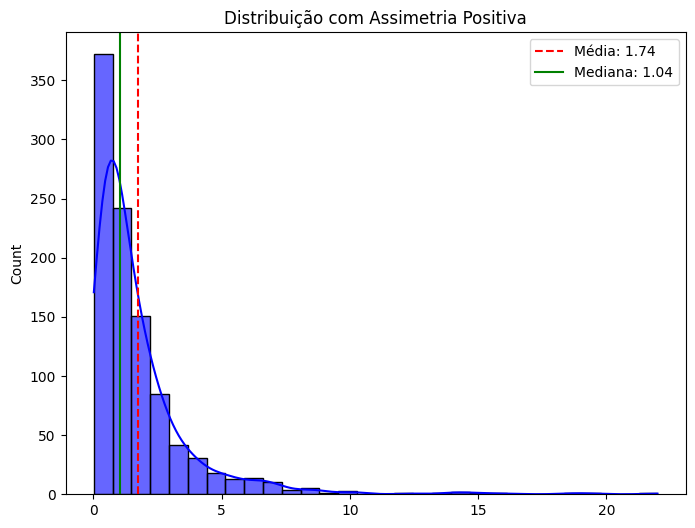

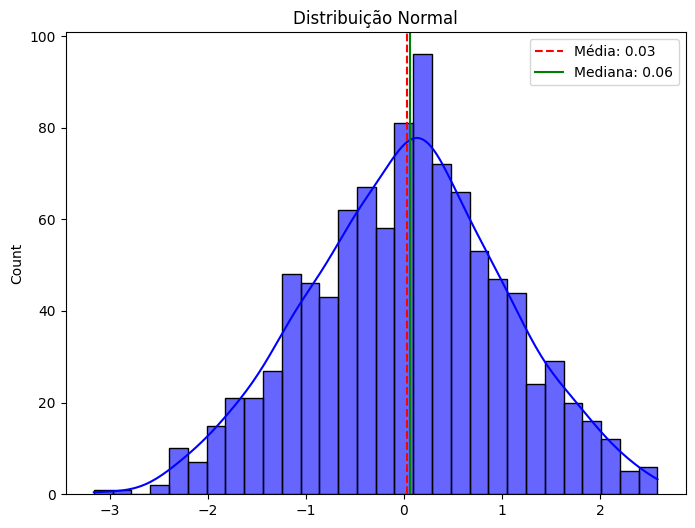

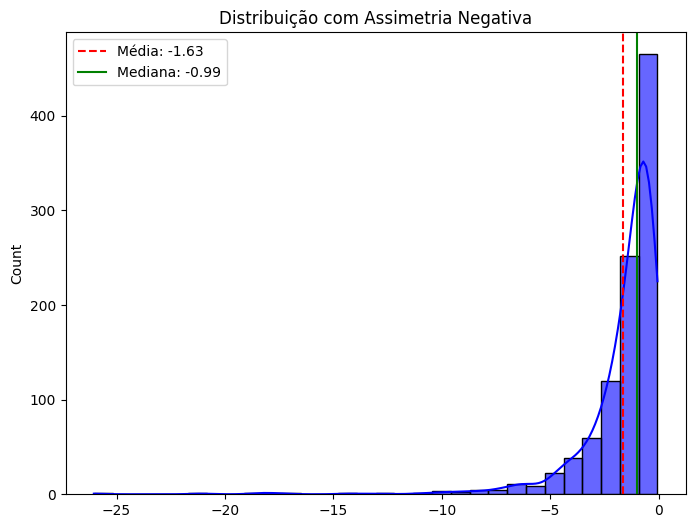

In [14]:
# Assimetria positiva
plot_distribution(data_pos_skew, "Distribuição com Assimetria Positiva", mean_pos, median_pos)

# Distribuição normal
plot_distribution(data_normal, "Distribuição Normal", mean_norm, median_norm)

# Assimetria negativa
plot_distribution(data_neg_skew, "Distribuição com Assimetria Negativa", mean_neg, median_neg)

**🔍 O Perigo das Médias e o Poder da Mediana**

Antes de modelarmos dados, precisamos descrevê-los corretamente. As três principais medidas de tendência central comportam-se de maneiras muito distintas dependendo da distribuição dos dados:

* **Média (Mean):** O centro de massa dos dados. É calculada somando todos os valores e dividindo pelo número de observações. 
  $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$
  *Cuidado:* É extremamente sensível a valores extremos (outliers).
* **Mediana (Median):** O valor que divide os dados exatamente ao meio quando ordenados. 50% dos dados estão abaixo dela, e 50% acima. É uma medida **robusta** a outliers.
* **Moda (Mode):** O valor mais frequente no conjunto de dados. Pode haver mais de uma (bimodal, multimodal) ou nenhuma (amodal).


#### Cenário 1: Vendas Mensais Regulares

In [26]:
vendas_cenario_1 = [15, 15, 25, 25, 30, 35, 40, 45, 50, 60, 60, 60]
df_vendas_1 = pd.Series(vendas_cenario_1)

print("--- CENÁRIO 1: Vendas Regulares ---")
print(f"Média:   {df_vendas_1.mean():.2f}")
print(f"Mediana: {df_vendas_1.median():.2f}")
print(f"Moda:    {df_vendas_1.mode()[0]}")

--- CENÁRIO 1: Vendas Regulares ---
Média:   38.33
Mediana: 37.50
Moda:    60


#### Cenário 2: A distorção causada por Outliers

Imagine que no mesmo período, tivemos lançamentos de projetos corporativos gigantescos em dois meses específicos e um erro de digitação em outro, gerando valores extremos. Veja o que acontece com as nossas métricas.

In [30]:
# Note que os dados do meio continuam muito parecidos, mas os extremos mudaram drasticamente.
vendas_cenario_2 = [15, 15, 25, 25, 30, 35, 40, 45, 50, 50, 5000, 6000]
df_vendas_2 = pd.Series(vendas_cenario_2)

print("--- CENÁRIO 2: Vendas com Outliers ---")
print(f"Média:   {df_vendas_2.mean():.2f}")
print(f"Mediana: {df_vendas_2.median():.2f}")
print(f"Moda:    {df_vendas_2.mode()[0]}")


--- CENÁRIO 2: Vendas com Outliers ---
Média:   944.17
Mediana: 37.50
Moda:    15


### 3. Medidas de Dispersão

#### 3.1 Variância
A **variância** mede o quanto os valores se afastam da média.

In [15]:
# Calculando a variância
variance_values = numeric_df.var()
print("Variância dos dados:\n", variance_values)

Variância dos dados:
 sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64


#### 3.2 Desvio Padrão
O **desvio padrão** é a raiz quadrada da variância, representando a dispersão dos dados.

In [16]:
# Calculando o desvio padrão
std_dev_values = numeric_df.std()
print("Desvio padrão dos dados:\n", std_dev_values)

Desvio padrão dos dados:
 sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64


#### 3.3 Amplitude
A **amplitude** é a diferença entre o maior e o menor valor de um conjunto de dados.

In [17]:
# Calculando a amplitude
range_values = numeric_df.max() - numeric_df.min()
print("Amplitude dos dados:\n", range_values)

Amplitude dos dados:
 sepal_length    3.6
sepal_width     2.4
petal_length    5.9
petal_width     2.4
dtype: float64


## 🎯 Mesma Média, Realidades Diferentes (Dispersão)

Avaliar apenas a média (ou até a mediana) oculta outra característica vital dos dados: a **Dispersão** (o quão espalhados os dados estão). 

**Contexto Prático:** Uma imobiliária possui uma equipe de corretores avaliando o mesmo imóvel, cujo valor de mercado real é R$ 500.000. 
* **Antes do Treinamento:** Os corretores chutavam valores muito discrepantes (alta dispersão).
* **Depois do Treinamento:** Os corretores aprenderam a calibrar suas avaliações, chegando a valores muito próximos ao real (baixa dispersão).

Vamos simular e visualizar essa diferença. A métrica que usaremos para medir a dispersão é o **Desvio Padrão**.

,mean,std
Momento,,
Antes do Treinamento,484423.02,136225.26
Depois do Treinamento,497069.20,20528.94


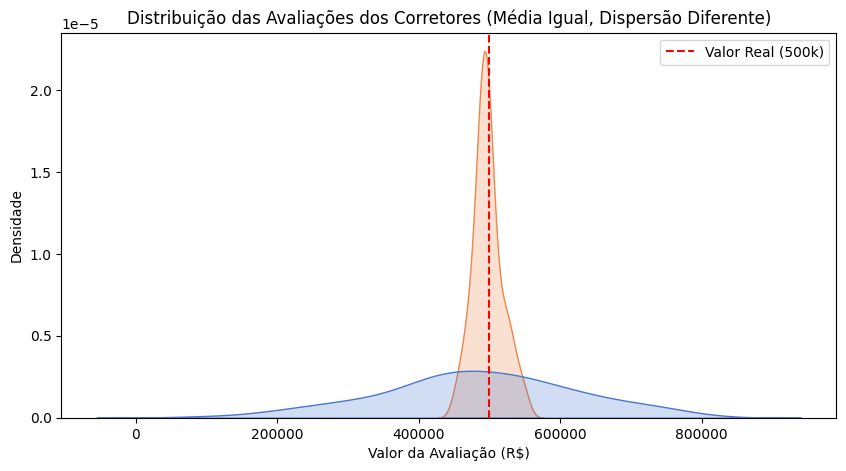

In [37]:
np.random.seed(42)
# Simulando 100 avaliações ANTES do treinamento (Média 500k, Desvio Padrão 150k)
antes_treinamento = np.random.normal(loc=500000, scale=150000, size=100)

# Simulando 100 avaliações DEPOIS do treinamento (Média 500k, mas Desvio Padrão cai para 20k)
np.random.seed(31)
depois_treinamento = np.random.normal(loc=500000, scale=20000, size=100)

# Criando um DataFrame para facilitar a plotagem
df_corretores = pd.DataFrame({
    'Avaliação': np.concatenate([antes_treinamento, depois_treinamento]),
    'Momento': ['Antes do Treinamento']*100 + ['Depois do Treinamento']*100
})

# Calculando Média e Desvio Padrão para os dois grupos
resumo = df_corretores.groupby('Momento')['Avaliação'].agg(['mean', 'std']).round(2)
display(resumo)

# Visualizando a diferença de dispersão
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_corretores, x='Avaliação', hue='Momento', fill=True, common_norm=False, palette="muted")
plt.axvline(x=500000, color='red', linestyle='--', label='Valor Real (500k)')
plt.title("Distribuição das Avaliações dos Corretores (Média Igual, Dispersão Diferente)")
plt.xlabel("Valor da Avaliação (R$)")
plt.ylabel("Densidade")
plt.legend()
plt.ticklabel_format(style='plain', axis='x') # Tira notação científica do eixo X
plt.show()

### 4. Visualizações Gráficas

#### 4.1 Histograma
Um **histograma** é uma representação gráfica da distribuição de um conjunto de dados.

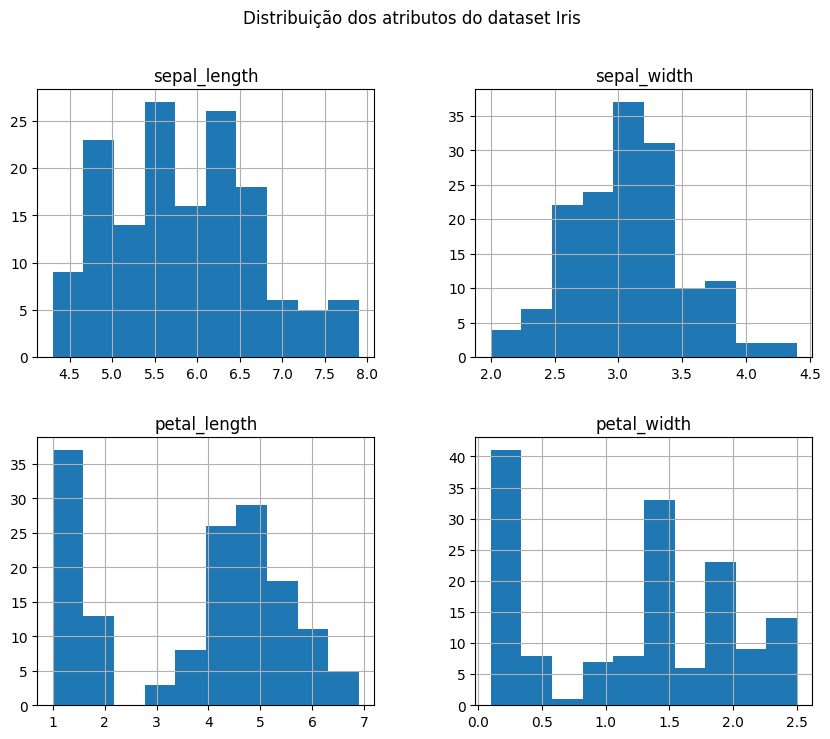

In [23]:
# Criando histogramas para cada característica do dataset iris
numeric_df.hist(bins=10, figsize=(10, 8))
plt.suptitle('Distribuição dos atributos do dataset Iris')
plt.show()

#### 4.2 Boxplot
Um **boxplot** visualiza a dispersão dos dados através de quartis, mostrando também os outliers.

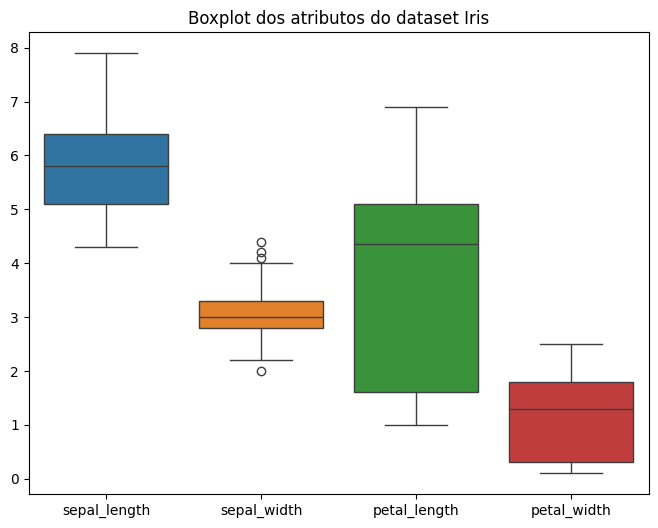

In [24]:
# Criando um boxplot para visualizar a dispersão dos dados
plt.figure(figsize=(8, 6))
sns.boxplot(data=numeric_df)
plt.title('Boxplot dos atributos do dataset Iris')
plt.show()

#### 4.3 Gráfico de Dispersão
Um **scatter plot** mostra a relação entre duas variáveis quantitativas.

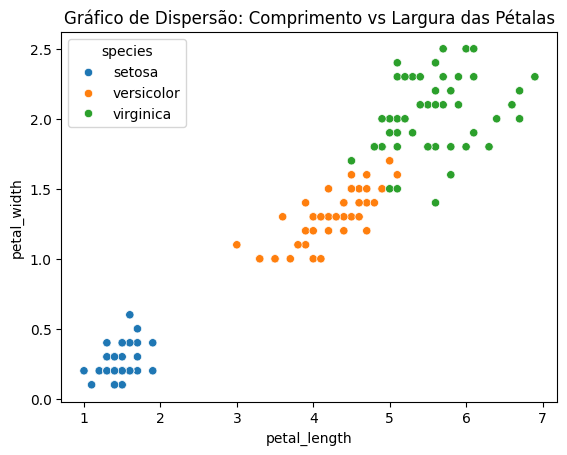

In [25]:
# Scatter plot para ver a relação entre comprimento e largura das pétalas
sns.scatterplot(x='petal_length', y='petal_width', data=df, hue='species')
plt.title('Gráfico de Dispersão: Comprimento vs Largura das Pétalas')
plt.show()

### 5. Conclusão

Nesta aula, exploramos as principais **medidas de tendência central** e **dispersão** e como elas podem ser aplicadas para entender a distribuição de dados. As visualizações gráficas são essenciais para obter insights mais profundos sobre as características dos dados e suas distribuições.
